# Extracción de datos — TP Integrador

**82.04 Analítica Descriptiva — ITBA**

Este notebook documenta la construcción del dataset maestro: la fuente elegida, el
proceso de extracción, los desafíos técnicos encontrados y la evidencia de que se
capturaron los cuatro tipos de dato que exige la consigna.

**Cliente definido:** pequeño inversor particular que evalúa comprar una unidad en
CABA para ponerla en alquiler.

## 1. Elección de la fuente

Se desarrollaron y evaluaron extractores para cuatro portales:

| Portal | Método | Resultado |
|---|---|---|
| Argenprop | HTML server-rendered | Funcional. Descartado por unicidad de criterio. |
| MercadoLibre | HTML + JSON embebido | Funcional. Descartado por unicidad de criterio. |
| Zonaprop | HTML + JSON embebido | **Bloqueado** por DataDome (ver sección 5). |
| **RE/MAX** | **API JSON pública** | **Fuente elegida.** |

### Por qué una sola fuente

Consolidar varios portales exige un cruce por dirección, superficie y precio para
detectar el mismo inmueble publicado en más de un sitio. Ese cruce es impreciso y
arrastra un error difícil de cuantificar. Además, cada portal normaliza distinto los
barrios, las superficies y las tipologías.

Se priorizó la **consistencia interna** sobre el volumen bruto.

### Ventaja adicional de RE/MAX

Es la única de las cuatro fuentes que expone **latitud y longitud** confiables, lo
que habilita los cruces espaciales con datos abiertos del GCBA previstos para la
Fase 3 (subte, espacios verdes, seguridad).

### Límite que impone

RE/MAX es una red inmobiliaria con cartera propia y exclusividades, no un clasificado
abierto. El dataset describe *su* oferta, no el mercado completo de CABA. Las
comparaciones entre barrios son válidas; los niveles absolutos deben leerse como
representativos de ese segmento.

## 2. Ejecución de la extracción

El scraping se ejecuta desde la línea de comandos con el CLI del proyecto:

```bash
py run_scrapers.py --portal remax --operacion ambas --paginas 200 --detalle
```

El flag `--detalle` resultó determinante: sin él, la API de listado no devuelve
antigüedad, dormitorios, cocheras ni descripciones. Una primera corrida sin ese flag
dejó **cinco variables completamente vacías**, entre ellas la antigüedad del edificio,
que es una de las variables de interés declaradas.

También puede invocarse desde Python:

```python
from src import remax
df = remax.scrape(operacion="venta", max_pages=200, con_detalle=True)
```

El resultado se consolida en `data/raw/dataset_maestro.csv`.

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

In [2]:
df = pd.read_csv("../data/raw/dataset_maestro.csv", encoding="utf-8-sig", low_memory=False)

print(f"Registros : {df.shape[0]:,}")
print(f"Variables : {df.shape[1]}")
print()
print(df.groupby(["portal", "operacion"]).size().to_string())

Registros : 14,867
Variables : 55

portal  operacion
remax   alquiler      1761
        venta        13106


### 2.1 Vista del dataframe maestro

In [3]:
df.head()

,portal,id_aviso,url,fecha_scraping,operacion,tipo_propiedad,precio_valor,precio_moneda,precio_texto,expensas_valor,expensas_moneda,direccion,calle,altura,piso,barrio,barrio_raw,comuna,localidad,latitud,longitud,sup_total_m2,sup_cubierta_m2,ambientes,dormitorios,banos,cocheras,antiguedad_anios,es_a_estrenar,precio_m2,titulo,descripcion,detalles,amenities,pileta,parrilla,gimnasio,sum,losa_radiante,aire_acondicionado,apto_credito,apto_profesional,cochera_txt,baulera,seguridad,luminoso,balcon,a_reciclar,reciclado,credito_uva,frente,amoblado,patio_jardin,ascensor,profesional_renta
0,remax,38213c01-e154-482f-9b8a-f80f50e2a10d,https://www.remax.com.ar/listings/alquiler-3-a...,2026-08-17T02:42:19+00:00,alquiler,departamento_estandar,950000.0,ARS,ARS 950000.0,180000.0,ARS,Franklin Delano Roosevelt 5200,Franklin Delano Roosevelt,5200.0,NaN,villa urquiza,Villa Urquiza,12,Capital Federal,-34.574411,-58.489102,49.00,49.00,3.0,2,1,0,56.0,0.0,19387.76,Alquiler 3 AMB Funcional a la calle - V. Urquiza,"Práctico, luminoso y funcional 3 Ambientes a l...",NaN,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1
1,remax,3828a2be-9ce1-45a2-812d-cc53afd8464f,https://www.remax.com.ar/listings/alquiler-mon...,2026-08-17T02:42:18+00:00,alquiler,departamento_monoambiente,560000.0,ARS,ARS 560000.0,90000.0,ARS,Cuba 2700,Cuba,2700.0,NaN,belgrano,Bajo Belgrano,13,Capital Federal,-34.555075,-58.460195,28.39,22.76,1.0,0,1,0,60.0,0.0,19725.26,ALQUILER MONOAMBIENTE BELGRANO CON PATIO,"MONOAMBIENTE EN ALQUILER DE 30 M² EN BELGRANO,...",Dormitorio Baño Cocina Patio Placard Living/Co...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
2,remax,3832ec48-b466-4067-829f-4e70eb727631,https://www.remax.com.ar/listings/alquiler-loc...,2026-08-17T02:42:17+00:00,alquiler,local,2000000.0,ARS,ARS 2000000.0,NaN,ARS,Granaderos 300,Granaderos,300.0,NaN,flores,Flores,7,Capital Federal,-34.623274,-58.460842,234.00,234.00,NaN,0,2,0,66.0,0.0,8547.01,Alquiler Local Calle Vivienda Sin Expensas Flores,LOCAL A LA CALLE + VIVIENDA – SIN EXPENSAS – F...,Electricidad Agua Baño Cocina Lavadero Toilet,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,remax,3874482b-d2f4-4dec-95d7-ea7eea7306cc,https://www.remax.com.ar/listings/alquiler-ofi...,2026-08-17T02:42:16+00:00,alquiler,oficina,450000.0,ARS,ARS 450000.0,244000.0,ARS,Av. Belgrano 1800,Av. Belgrano,1800.0,NaN,balvanera,Balvanera,3,Capital Federal,-34.613290,-58.393879,55.00,55.00,NaN,0,2,0,51.0,0.0,8181.82,Alquiler oficina reciclada y muy luminosa,Valor locativo mensual $450.000.- + IVA Oficin...,Electricidad Agua Seguridad Ascensor Recepción...,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0
4,remax,38a5908e-e13f-4367-86b0-50c2c94988f5,https://www.remax.com.ar/listings/alquilo-2-am...,2026-08-17T02:42:14+00:00,alquiler,departamento_estandar,800000.0,ARS,ARS 800000.0,155000.0,ARS,Vilela 2600,Vilela,2600.0,NaN,saavedra,Saavedra,12,Capital Federal,-34.546856,-58.473047,46.31,39.13,2.0,1,1,0,29.0,0.0,17274.89,ALQUILO 2 AMB AL FRENTE CON BALCON LUMIN SAAVEDRA,DEPARTAMENTO 2 AMBIENTES EN ALQUILER AL FRENTE...,Electricidad Gas Agua Corriente Dormitorio Bañ...,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14867 entries, 0 to 14866
Data columns (total 55 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   portal              14867 non-null  object 
 1   id_aviso            14867 non-null  object 
 2   url                 14867 non-null  object 
 3   fecha_scraping      14867 non-null  object 
 4   operacion           14867 non-null  object 
 5   tipo_propiedad      14867 non-null  object 
 6   precio_valor        14794 non-null  float64
 7   precio_moneda       14867 non-null  object 
 8   precio_texto        14867 non-null  object 
 9   expensas_valor      13859 non-null  float64
 10  expensas_moneda     14866 non-null  object 
 11  direccion           14867 non-null  object 
 12  calle               14867 non-null  object 
 13  altura              14856 non-null  float64
 14  piso                46 non-null     float64
 15  barrio              14867 non-null  object 
 16  barr

## 3. Evidencia de los cuatro tipos de dato

La consigna pide demostrar la captura de datos **textuales, numéricos, ordinales y
dicotómicos**. El esquema unificado de 55 columnas cubre los cuatro.

In [5]:
TIPOS = {
    "Numéricas (continuas y discretas)": [
        "precio_valor", "sup_total_m2", "sup_cubierta_m2", "ambientes", "dormitorios",
        "banos", "cocheras", "antiguedad_anios", "expensas_valor", "latitud",
        "longitud", "precio_m2",
    ],
    "Textuales / categóricas nominales": [
        "portal", "operacion", "tipo_propiedad", "barrio", "calle", "titulo",
        "descripcion", "precio_moneda",
    ],
    "Ordinales": ["comuna", "piso"],
    "Dicotómicas (0/1)": [
        "amenities", "pileta", "parrilla", "gimnasio", "sum", "losa_radiante",
        "aire_acondicionado", "apto_credito", "apto_profesional", "cochera_txt",
        "baulera", "seguridad", "luminoso", "balcon", "a_reciclar", "reciclado",
        "credito_uva", "frente", "amoblado", "patio_jardin", "ascensor",
        "profesional_renta", "es_a_estrenar",
    ],
}

for tipo, cols in TIPOS.items():
    presentes = [c for c in cols if c in df.columns]
    print(f"{tipo}: {len(presentes)} variables")
    print("   ", ", ".join(presentes))
    print()

Numéricas (continuas y discretas): 12 variables
    precio_valor, sup_total_m2, sup_cubierta_m2, ambientes, dormitorios, banos, cocheras, antiguedad_anios, expensas_valor, latitud, longitud, precio_m2

Textuales / categóricas nominales: 8 variables
    portal, operacion, tipo_propiedad, barrio, calle, titulo, descripcion, precio_moneda

Ordinales: 2 variables
    comuna, piso

Dicotómicas (0/1): 23 variables
    amenities, pileta, parrilla, gimnasio, sum, losa_radiante, aire_acondicionado, apto_credito, apto_profesional, cochera_txt, baulera, seguridad, luminoso, balcon, a_reciclar, reciclado, credito_uva, frente, amoblado, patio_jardin, ascensor, profesional_renta, es_a_estrenar



### 3.1 Numéricas

Magnitudes sobre las que tiene sentido calcular medias, medianas y dispersión.

In [6]:
NUM = ["precio_valor", "sup_total_m2", "sup_cubierta_m2", "ambientes",
       "dormitorios", "banos", "antiguedad_anios", "expensas_valor"]

df[NUM].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
precio_valor,14794.0,2.601191e+05,4.594240e+05,350.0,85000.0,140000.00,255000.00,1.500000e+07
sup_total_m2,14867.0,1.663300e+02,2.684680e+03,0.0,42.0,65.00,114.00,1.940000e+05
sup_cubierta_m2,14867.0,1.406300e+02,2.677110e+03,0.0,37.0,54.46,86.75,1.940000e+05
ambientes,12829.0,2.820000e+00,1.800000e+00,1.0,2.0,3.00,4.00,1.200000e+02
dormitorios,14867.0,1.570000e+00,1.560000e+00,0.0,1.0,1.00,2.00,4.700000e+01
banos,14867.0,1.290000e+00,1.090000e+00,0.0,1.0,1.00,1.00,4.700000e+01
antiguedad_anios,14527.0,3.489000e+01,2.551000e+01,-3.0,10.0,40.00,55.00,1.900000e+02
expensas_valor,13859.0,8.017253e+12,9.438251e+14,0.0,0.0,124000.00,230000.00,1.111111e+17


### 3.2 Textuales y categóricas

El precio se captura **separado en valor numérico y moneda**, no como string. Es una
mejora sobre el script base de la cátedra, que lo dejaba como `"USD 145.000"` —
imposible de promediar.

In [7]:
for c in ["operacion", "tipo_propiedad", "precio_moneda"]:
    print(f"--- {c} ({df[c].nunique()} valores distintos) ---")
    print(df[c].value_counts().head(6).to_string())
    print()

--- operacion (2 valores distintos) ---
operacion
venta       13106
alquiler     1761

--- tipo_propiedad (23 valores distintos) ---
tipo_propiedad
departamento_estandar        7808
ph                           1525
departamento_monoambiente    1398
casa                          681
oficina                       524
cochera                       524

--- precio_moneda (2 valores distintos) ---
precio_moneda
USD    13527
ARS     1340



In [8]:
# El barrio se normaliza contra los 48 barrios oficiales de CABA,
# resolviendo alias del tipo "Palermo Hollywood" -> "palermo".
print(f"Barrios normalizados: {df['barrio'].nunique()} de 48 oficiales")
print(f"Comunas cubiertas   : {int(df['comuna'].nunique())} de 15")
print()
print(df["barrio"].value_counts().head(10).to_string())

Barrios normalizados: 48 de 48 oficiales
Comunas cubiertas   : 15 de 15

barrio
palermo          1592
caballito        1047
recoleta          819
belgrano          803
balvanera         736
almagro           685
flores            630
san nicolas       622
villa urquiza     576
villa crespo      521


### 3.3 Ordinales

`comuna` tiene un orden natural (1 a 15) y se deriva del barrio normalizado.

In [9]:
df["comuna"].value_counts().sort_index().to_frame("avisos")

,avisos
comuna,
1,1736
2,819
3,1060
4,556
5,922
6,1047
7,876
8,258
9,517


### 3.4 Dicotómicas

Se construyen aplicando expresiones regulares sobre el texto libre de título,
descripción y detalles. Esta es la etapa de *feature engineering* que la consigna
menciona para la 2da pre-entrega, adelantada acá porque depende de la extracción.

In [10]:
DUMMIES = ["balcon", "cochera_txt", "amenities", "ascensor", "aire_acondicionado",
           "pileta", "parrilla", "apto_credito", "luminoso", "patio_jardin",
           "seguridad", "baulera", "amoblado", "a_reciclar", "reciclado",
           "losa_radiante", "gimnasio", "sum", "es_a_estrenar"]

prevalencia = (df[DUMMIES].mean() * 100).round(1).sort_values(ascending=False)
prevalencia.to_frame("% de avisos con la característica")

,% de avisos con la característica
balcon,67.7
luminoso,41.0
ascensor,40.8
amenities,38.0
aire_acondicionado,37.7
cochera_txt,32.9
parrilla,27.8
patio_jardin,27.1
apto_credito,19.5
pileta,16.8


**Nota metodológica.** Estas variables solo tienen valor si el scraping se corre con
`--detalle`. En una primera corrida sin ese flag, las dummies solo podían leer el
título del aviso, y quedaban sistemáticamente subestimadas: `ascensor` daba 0,1% y
`losa_radiante` 0,0%. No es que los departamentos no tuvieran ascensor — es que nadie
lo escribe en el título. Con las descripciones completas, `ascensor` pasó a 39,7%.

## 4. Completitud del dataset

Las variables de interés declaradas en el proyecto —ambientes, barrio, superficie,
antigüedad, precio— se capturaron con alta cobertura.

In [11]:
CLAVE = ["precio_valor", "precio_moneda", "sup_total_m2", "sup_cubierta_m2",
         "ambientes", "dormitorios", "banos", "antiguedad_anios", "barrio",
         "comuna", "latitud", "longitud", "expensas_valor", "descripcion"]

completitud = pd.DataFrame({
    "no nulos": df[CLAVE].notna().sum(),
    "% completitud": (df[CLAVE].notna().mean() * 100).round(1),
}).sort_values("% completitud", ascending=False)

completitud

,no nulos,% completitud
precio_moneda,14867,100.0
sup_total_m2,14867,100.0
dormitorios,14867,100.0
sup_cubierta_m2,14867,100.0
barrio,14867,100.0
banos,14867,100.0
comuna,14867,100.0
descripcion,14867,100.0
longitud,14858,99.9
latitud,14858,99.9


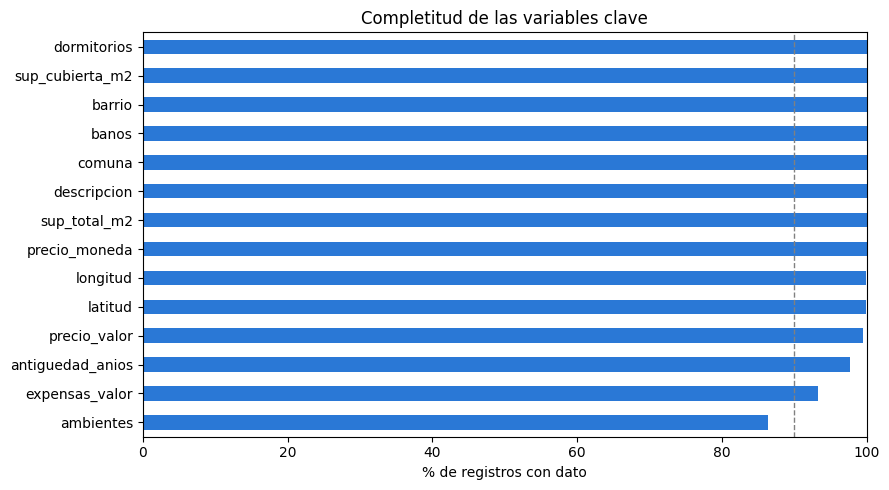

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
completitud["% completitud"].sort_values().plot(kind="barh", ax=ax, color="#2a78d6")
ax.set_xlabel("% de registros con dato")
ax.set_title("Completitud de las variables clave")
ax.set_xlim(0, 100)
ax.axvline(90, color="grey", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

## 5. Desafíos técnicos encontrados

La consigna pide documentar los bloqueos y cómo fueron sorteados. Se encontraron
cuatro, de distinta naturaleza.

### 5.1 Compresión Brotli — el bug silencioso

**Síntoma.** Tres de los cuatro portales devolvían **cero avisos**. Status HTTP 200,
respuestas de ~290 KB, ninguna excepción. Todo indicaba un cambio de selectores CSS.

**Diagnóstico.** Al inspeccionar el HTML guardado, el contenido era **78% de bytes no
imprimibles**: no era HTML, era un blob binario.

**Causa.** El scraper declaraba `Accept-Encoding: gzip, deflate, br` pero el paquete
`Brotli` no estaba instalado. El servidor toma la palabra y responde comprimido,
`urllib3` no sabe descomprimirlo y entrega los bytes crudos.

Argenprop nunca falló porque su CDN devuelve **gzip**, que la librería estándar sí
descomprime. Esa asimetría hacía parecer que el problema era de los otros portales.

**Por qué es insidioso.** No falla ruidosamente: no hay excepción, el status es 200 y
el tamaño del body es el esperable. Es indistinguible de un problema de selectores.

**Solución, en dos capas** (`src/utils.py`):
1. Declarar únicamente los codecs que el entorno puede descomprimir, verificándolo en
   tiempo de import.
2. Una red de seguridad que detecta un cuerpo binario y lo descomprime a mano, por si
   el servidor comprime aunque no se lo pidamos.

### 5.2 Huella TLS

`requests` tiene un *fingerprint* TLS (JA3) que no coincide con el de ningún navegador.
Los anti-bot comerciales lo detectan **en el handshake, antes de leer un solo header**,
por lo que declarar un User-Agent de Chrome no ayuda. Se resolvió con `curl_cffi`, que
replica el handshake exacto de Chrome.

### 5.3 Zonaprop y DataDome

Es el portal de mayor volumen del mercado y el más protegido: fingerprinting de TLS,
challenge de JavaScript, rate limiting por IP y captcha. Ninguna librería HTTP resuelve
el challenge de JS. Se implementó un plan B con Playwright, que corre un Chromium real,
pero la fragilidad del enfoque sumada a la decisión de fuente única llevó a descartarlo.

### 5.4 API oficial de MercadoLibre

MercadoLibre cerró el acceso anónimo a `api.mercadolibre.com`; hoy exige un token de
aplicación registrada. Por eso se scrapeó HTML.

In [13]:
# El motor HTTP y los codecs disponibles se reportan al arrancar cualquier corrida
import sys
sys.path.insert(0, "..")
from src import utils

print(utils.info_backend())

HTTP: curl_cffi (imita TLS de Chrome)  |  Accept-Encoding: gzip, deflate, br, zstd


## 6. Hallazgos de calidad del dato

La inspección del dataset crudo detectó tres problemas que condicionan el análisis
posterior. Se documentan acá porque surgen de la extracción; su tratamiento está en
`limpieza.py`.

### 6.1 Cuatro unidades distintas en una sola columna

`precio_m2` se calcula como `precio_valor / sup_total_m2` sin conversión de moneda,
por lo que mezcla unidades incompatibles.

In [14]:
resumen_monedas = (df.groupby(["operacion", "precio_moneda"])["precio_m2"]
                     .agg(["count", "median"])
                     .round(1))
resumen_monedas

count   median
operacion precio_moneda                
alquiler  ARS             1338  17981.2
          USD              419     15.7
venta     ARS                1  14962.6
          USD            13031   1902.4

Además de la moneda hay un problema **dimensional**: en venta es un precio (un stock),
en alquiler es un flujo mensual. No son comparables ni expresados en la misma moneda.

Un `groupby("barrio")["precio_m2"].mean()` sobre el crudo devuelve un número sin
significado. El dataset limpio lo resuelve creando columnas cuyo nombre **declara la
unidad**: `venta_usd`, `alquiler_usd_mes`, `venta_m2_usd`, `alquiler_m2_usd_mes`.

### 6.2 Errores de carga del publicador

Seis avisos tienen la moneda o la operación mal cargadas en el portal.

In [15]:
# Publicado como venta en ARS, pero el título y el monto son de alquiler
mal_cargado = df[(df.operacion == "venta") & (df.precio_moneda == "ARS")]
mal_cargado[["id_aviso", "precio_valor", "precio_moneda", "sup_total_m2", "titulo"]]

,id_aviso,precio_valor,precio_moneda,sup_total_m2,titulo
5894,768037e0-4549-443b-8719-687b7487f2b9,600000.0,ARS,40.1,DEPARTAMENTO ALQUILER 2 AMB EXCELENTE UBICACION


In [16]:
# Publicados como alquiler en USD, pero el monto solo tiene sentido en pesos
sospechosos = df[(df.operacion == "alquiler") &
                 (df.precio_moneda == "USD") &
                 (df.precio_valor > 100_000)]

sospechosos[["precio_valor", "sup_total_m2", "barrio", "titulo"]].sort_values("precio_valor")

,precio_valor,sup_total_m2,barrio,titulo
535,650000.0,694.00,palermo,Alquiler Monoambiente divisible en Palerm
1222,650000.0,30.00,palermo,ALQUILER MONOAMBIENTE CON BALCON PALERMO
1675,1000000.0,179.29,san nicolas,ALQUILER-OFICINAS -AV. CORRIENTES 400-SAN NICOLAS
111,2400000.0,220.00,flores,ALQUILER LOCAL COMERCIAL CARABOBO 900 EN ESQUINA


In [17]:
# Verificación: leídos como ARS/m²/mes, ¿son coherentes con el mercado?
mediana_ars = (df[(df.operacion == "alquiler") & (df.precio_moneda == "ARS")]
                 .eval("precio_valor / sup_total_m2").median())

print(f"Mediana de alquiler en pesos: {mediana_ars:,.0f} ARS/m²/mes")
print()
for _, r in sospechosos.iterrows():
    print(f"  {r.precio_valor:>12,.0f} / {r.sup_total_m2:>6.1f} m² = "
          f"{r.precio_valor / r.sup_total_m2:>9,.0f} ARS/m²/mes")

Mediana de alquiler en pesos: 17,982 ARS/m²/mes

     2,400,000 /  220.0 m² =    10,909 ARS/m²/mes
       650,000 /  694.0 m² =       937 ARS/m²/mes
       650,000 /   30.0 m² =    21,667 ARS/m²/mes
     1,000,000 /  179.3 m² =     5,578 ARS/m²/mes


Leídos como dólares son absurdos: un monoambiente de 30 m² a USD 650.000 mensuales
equivaldría a 21.667 USD por m² **por mes**, más de diez veces lo que cuesta *comprar*
el metro cuadrado en Palermo. Leídos como pesos caen dentro del rango normal del
mercado, entre los percentiles 30 y 95 de los alquileres publicados en pesos.

El impacto de corregirlos es desproporcionado a su cantidad:

In [18]:
# Solo los avisos con precio informado (los nulos no participan del promedio)
usd = df[(df.operacion == "alquiler") &
         (df.precio_moneda == "USD") &
         (df.precio_valor.notna())]

mal_cargados = usd[usd.precio_valor > 100_000]
sin_error = usd[usd.precio_valor <= 100_000]

print(f"Alquileres en USD con precio : {len(usd)}")
print(f"Registros mal cargados       : {len(mal_cargados)}")
print()
print(f"Media con los errores  : USD {usd.precio_valor.mean():>10,.0f}")
print(f"Media sin los errores  : USD {sin_error.precio_valor.mean():>10,.0f}")
print(f"Reducción              : {(1 - sin_error.precio_valor.mean()/usd.precio_valor.mean())*100:>9.0f}%")

Alquileres en USD con precio : 419
Registros mal cargados       : 4

Media con los errores  : USD     14,172
Media sin los errores  : USD      2,983
Reducción              :        79%


Un puñado de registros mal cargados distorsionaba toda la serie. Este es el tipo de
error que no genera ninguna excepción y pasa desapercibido si no se inspeccionan los
valores extremos.

### 6.3 Tipos de propiedad no residenciales

El scraping captura toda la cartera del portal, incluyendo activos que no responden a
la tesis de inversión del cliente definido.

In [19]:
RESIDENCIAL = ["departamento_estandar", "departamento_monoambiente", "ph",
               "departamento_semipiso", "departamento_duplex", "departamento_piso",
               "departamento_loft", "departamento_triplex", "departamento_penthouse",
               "casa", "casa_duplex", "casa_triplex"]

es_resid = df.tipo_propiedad.isin(RESIDENCIAL)
print(f"Residencial     : {es_resid.sum():>6,}")
print(f"No residencial  : {(~es_resid).sum():>6,}")
print()
print(df.loc[~es_resid, "tipo_propiedad"].value_counts().to_string())

Residencial     : 12,636
No residencial  :  2,231

tipo_propiedad
oficina              524
cochera              524
local                509
terrenos_y_lotes     406
deposito              92
galpon                57
edificio              44
consultorio           34
fondo_de_comercio     19
hotel                 18
otros                  4


## 7. Resultado de la extracción

| | Valor |
|---|---:|
| Avisos capturados | 14.867 |
| Variables | 55 |
| Operaciones de venta | 13.106 |
| Operaciones de alquiler | 1.761 |
| Barrios cubiertos | 48 de 48 |
| Comunas cubiertas | 15 de 15 |

**Los cuatro tipos de dato están presentes:** 12 numéricas, 8 textuales/categóricas,
2 ordinales y 23 dicotómicas.

### Limitaciones declaradas

1. **Fuente única.** El dataset refleja la cartera de RE/MAX, no el mercado completo.
2. **Corte temporal único.** No permite análisis de series ni estacionalidad; el
   *time to sell* y la evolución de precios requieren recolección periódica.
3. **Precios de publicación, no de cierre.** En un mercado con negociación, el precio
   final suele ser menor.
4. **Desbalance venta/alquiler.** Hay 7,4 avisos de venta por cada uno de alquiler, lo
   que obliga a estimar el alquiler esperado mediante un modelo en lugar de observarlo
   directamente.

### Próximo paso

La limpieza y el tratamiento de estos hallazgos se ejecutan con:

```bash
py limpieza.py --tc 1500
```

que produce `data/processed/dataset_limpio.csv` y deja registrado en
`dataset_excluidos.csv` cada registro descartado con su motivo.